## Threshold Tuning for Fraud Prediction Decisions

#### Import packages

In [1]:
# Import Packages

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    average_precision_score,
    roc_auc_score
)

#### Load cleaned data

In [2]:
data = pd.read_parquet(
    "../data/processed/train_transaction_cleaned.parquet", 
    engine='fastparquet'
)

#### Prepare features and targets

In [3]:
X = data.drop(columns=['isFraud', 'TransactionID'])
y = data['isFraud']

X = X.select_dtypes(include=["number"])

#### Chronological Split

In [4]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_validation = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_validation = y.iloc[split_index:]

#### Train the same XGBoost model

In [7]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


#### Get fraud probabilities

In [8]:
y_probability = xgb_model.predict_proba(X_validation)[:, 1]

#### Test different thresholds

In [14]:
thresholds = np.arange(0.05, 0.95, 0.05)

results = []

for threshold in thresholds:
    y_pred_threshold = (y_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        y_pred_threshold
    ).ravel()

    precision = precision_score(y_validation, y_pred_threshold)
    recall = recall_score(y_validation, y_pred_threshold)
    f1 = f1_score(y_validation, y_pred_threshold)

    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision,recall,f1_score,true_positives,false_positives,false_negatives,true_negatives
0,0.05,0.039713,0.996801,0.076383,4051,97956,13,16088
1,0.10,0.049952,0.976624,0.095043,3969,75487,95,38557
2,0.15,0.061547,0.956693,0.115654,3888,59283,176,54761
3,0.20,0.074696,0.926427,0.138246,3765,46639,299,67405
4,0.25,0.094174,0.893701,0.170392,3632,34935,432,79109
5,0.30,0.114452,0.861713,0.202066,3502,27096,562,86948
6,0.35,0.135158,0.831201,0.232509,3378,21615,686,92429
7,0.40,0.156936,0.800935,0.262447,3255,17486,809,96558
8,0.45,0.178703,0.763533,0.289621,3103,14261,961,99783
9,0.50,0.202543,0.729085,0.317017,2963,11666,1101,102378


#### Sort by F1 Score

In [15]:
threshold_results.sort_values(by="f1_score", ascending=False).head(10)

,threshold,precision,recall,f1_score,true_positives,false_positives,false_negatives,true_negatives
16,0.85,0.597426,0.411171,0.487101,1671,1126,2393,112918
15,0.80,0.492159,0.463337,0.477313,1883,1943,2181,112101
17,0.90,0.731221,0.352116,0.475336,1431,526,2633,113518
14,0.75,0.401898,0.510581,0.449767,2075,3088,1989,110956
13,0.70,0.335088,0.563976,0.420396,2292,4548,1772,109496
12,0.65,0.291225,0.614911,0.395255,2499,6082,1565,107962
11,0.60,0.256830,0.652313,0.368553,2651,7671,1413,106373
10,0.55,0.227546,0.689469,0.342166,2802,9512,1262,104532
9,0.50,0.202543,0.729085,0.317017,2963,11666,1101,102378
8,0.45,0.178703,0.763533,0.289621,3103,14261,961,99783


#### Sort by Precision

In [16]:
threshold_results.sort_values(by="precision", ascending=False).head(10)

,threshold,precision,recall,f1_score,true_positives,false_positives,false_negatives,true_negatives
17,0.90,0.731221,0.352116,0.475336,1431,526,2633,113518
16,0.85,0.597426,0.411171,0.487101,1671,1126,2393,112918
15,0.80,0.492159,0.463337,0.477313,1883,1943,2181,112101
14,0.75,0.401898,0.510581,0.449767,2075,3088,1989,110956
13,0.70,0.335088,0.563976,0.420396,2292,4548,1772,109496
12,0.65,0.291225,0.614911,0.395255,2499,6082,1565,107962
11,0.60,0.256830,0.652313,0.368553,2651,7671,1413,106373
10,0.55,0.227546,0.689469,0.342166,2802,9512,1262,104532
9,0.50,0.202543,0.729085,0.317017,2963,11666,1101,102378
8,0.45,0.178703,0.763533,0.289621,3103,14261,961,99783


#### Find a practical threshold

In [17]:
# We not only want the best F1 score, but also a threshold that gives us a reasonable balance.

threshold_results[
    [
        "threshold",
        "precision",
        "recall",
        "f1_score",
        "false_positives",
        "false_negatives"
    ]
]

,threshold,precision,recall,f1_score,false_positives,false_negatives
0,0.05,0.039713,0.996801,0.076383,97956,13
1,0.10,0.049952,0.976624,0.095043,75487,95
2,0.15,0.061547,0.956693,0.115654,59283,176
3,0.20,0.074696,0.926427,0.138246,46639,299
4,0.25,0.094174,0.893701,0.170392,34935,432
5,0.30,0.114452,0.861713,0.202066,27096,562
6,0.35,0.135158,0.831201,0.232509,21615,686
7,0.40,0.156936,0.800935,0.262447,17486,809
8,0.45,0.178703,0.763533,0.289621,14261,961
9,0.50,0.202543,0.729085,0.317017,11666,1101


#### Plot precision, recall, and F1

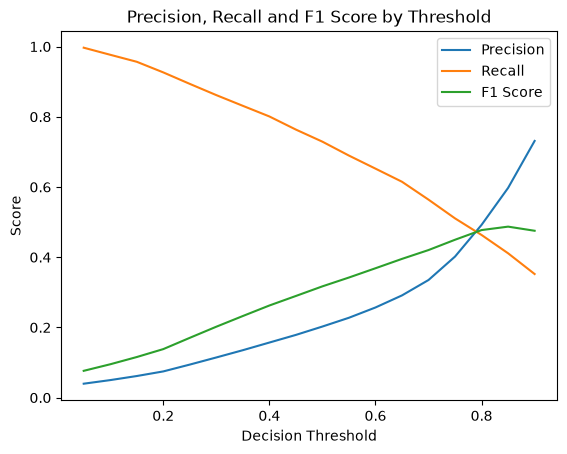

In [18]:
import matplotlib.pyplot as plt

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1_score"],
    label="F1 Score"
)

plt.title("Precision, Recall and F1 Score by Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

## Threshold Tuning Summary

The XGBoost model outputs fraud probabilities, but the final fraud decision depends on the chosen threshold. Instead of using the default `0.5` cutoff, multiple thresholds from `0.05` to `0.90` were tested to compare precision, recall, F1 score, false positives and false negatives.

The best F1 score was achieved at a threshold of `0.85`:

- Precision: 0.597
- Recall: 0.411
- F1 score: 0.487
- True Positives: 1,671
- False Positives: 1,126
- False Negatives: 2,393
- True Negatives: 112,918

At the default `0.05` threshold, the model detected more fraud cases but also created many more false positives: 

- Precision: 0.203
- Recall: 0.729
- F1 score: 0.317
- True Positives: 2,963
- False Positives: 11,666
- False Negatives: 1,101
- True Negatives: 102,378

Raising the threshold from `0.50` to `0.85` reduced the false positives from 11,666 to 1,126, a reduction of `90.34%`. However, recall decreased from `0.729` to `0.411`, meaning the model caught fewer fraudulent transactions.

Therefore, the threshold of `0.85` provides a strong balance between fraud detection and false-positive control.